# Módulo 2: Visualización estadística atractiva con Seaborn

En este módulo exploraremos **Seaborn**, una biblioteca basada en Matplotlib diseñada para crear gráficos estadísticos atractivos y fáciles de interpretar. Aprenderás a representar distribuciones de datos, relaciones entre variables y matrices de correlación utilizando funciones de alto nivel. Al final serás capaz de elegir la visualización adecuada para tus datos y personalizar el estilo del gráfico.

## Preparación del entorno

Antes de empezar, importamos las bibliotecas necesarias. Seaborn se construye sobre Matplotlib y trabaja de forma natural con pandas, por lo que también importaremos estas herramientas. Además configuramos un estilo base para que todos los gráficos tengan una apariencia coherente.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración básica de estilo
sns.set_theme(style="darkgrid", palette="deep")  # se puede experimentar con otros estilos y paletas

%matplotlib inline

## 1. Distribuciones de datos

La exploración inicial de un conjunto de datos suele comenzar analizando cómo se distribuyen sus variables. Seaborn ofrece varias funciones para visualizar la frecuencia o densidad de los valores. Comenzaremos con histogramas y estimaciones de densidad (KDE), y luego compararemos estos con boxplots y violin plots para detectar valores atípicos.

### 1.1 Histogramas y estimaciones de densidad

Un **histograma** muestra cómo se distribuyen los valores de una variable dividiendo el eje horizontal en barras (bins) y contando cuántas observaciones caen en cada una. Ajustar el ancho o número de barras cambia el nivel de detalle. Una **estimación de densidad** usa un kernel para suavizar la distribución; es útil para identificar multimodalidad sin depender del tamaño de las barras.

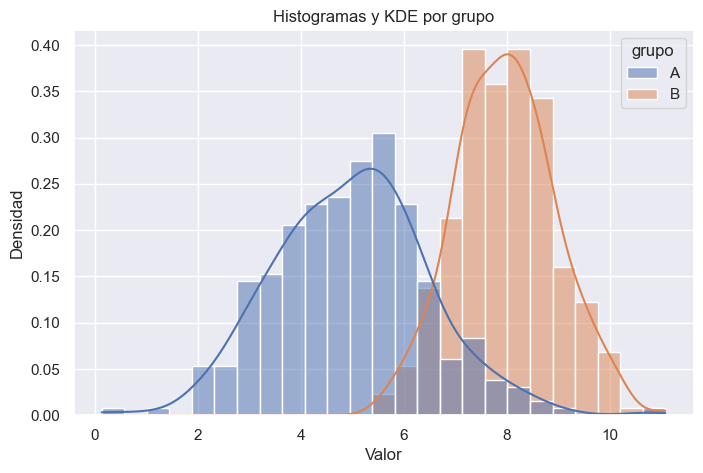

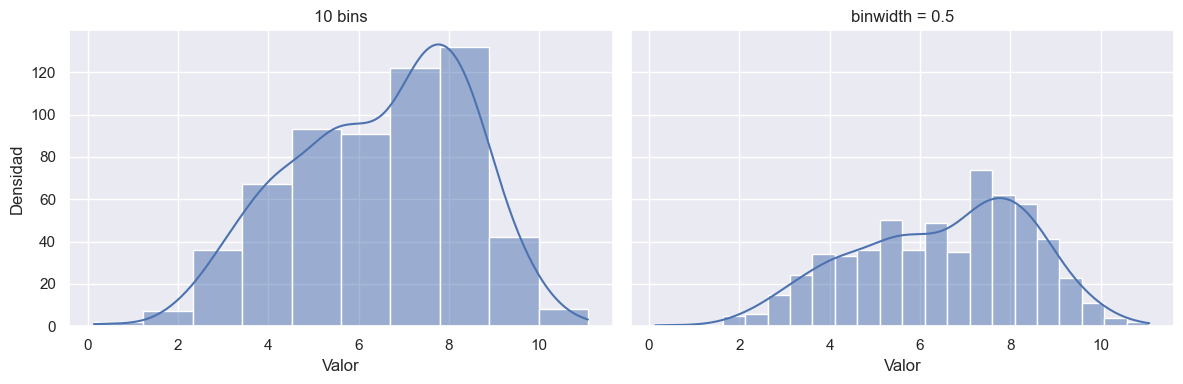

In [2]:
# Generamos datos sintéticos: dos grupos con distribuciones diferentes
np.random.seed(42)
grupo_a = np.random.normal(loc=5, scale=1.5, size=300)
grupo_b = np.random.normal(loc=8, scale=1.0, size=300)

datos = pd.DataFrame({
    "valor": np.concatenate([grupo_a, grupo_b]),
    "grupo": ["A"] * len(grupo_a) + ["B"] * len(grupo_b)
})

# Histograma con estimación de densidad para cada grupo
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=datos, x="valor", hue="grupo", element="bars", stat="density",
             common_norm=False, bins=25, kde=True, ax=ax)
ax.set_title("Histogramas y KDE por grupo")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.show()

# Comparación de binwidth vs bins
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(datos["valor"], bins=10, kde=True, ax=axes[0])
axes[0].set_title("10 bins")

sns.histplot(datos["valor"], binwidth=0.5, kde=True, ax=axes[1])
axes[1].set_title("binwidth = 0.5")
for ax in axes:
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

### 1.2 Boxplots y violin plots para detectar outliers

Los **boxplots** representan la mediana y los cuartiles de una distribución. La caja muestra el rango intercuartílico (IQR), mientras que las líneas (bigotes) se extienden a 1.5 × IQR; los puntos que quedan fuera de este rango se consideran *valores atípicos*. Un **violin plot** combina la información del boxplot con una estimación de densidad, mostrando la forma de la distribución a ambos lados de la mediana.

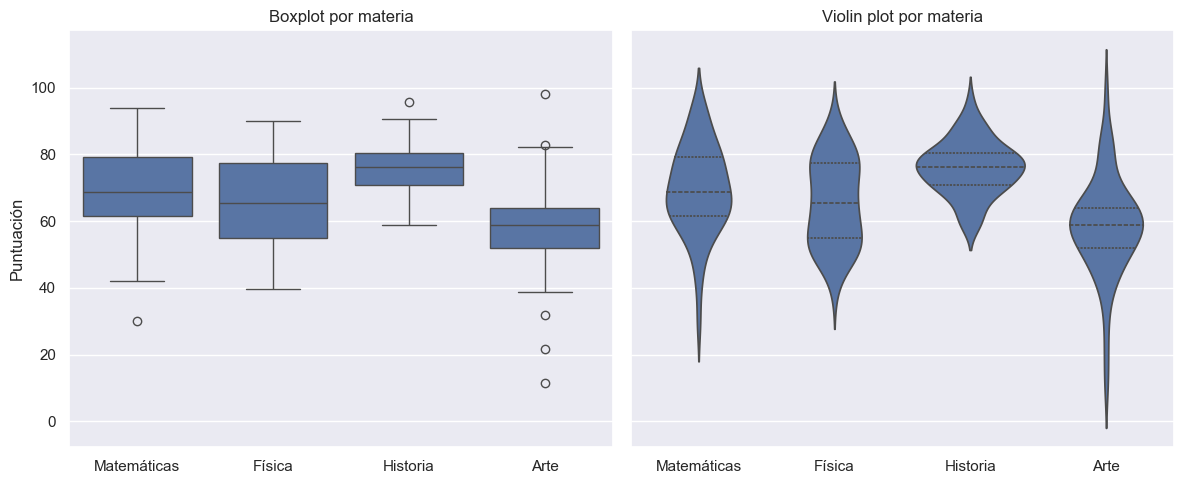

In [3]:
# Creamos un DataFrame con puntuaciones de examen para diferentes materias
np.random.seed(123)
materias = ["Matemáticas", "Física", "Historia", "Arte"]
datos_box = pd.DataFrame({
    "materia": np.repeat(materias, 50),
    "puntuación": np.concatenate([
        np.random.normal(70, 10, 50),    # Matemáticas
        np.random.normal(65, 12, 50),    # Física
        np.random.normal(75, 8, 50),     # Historia
        np.random.normal(60, 15, 50)     # Arte
    ])
})

# Introducimos algunos valores atípicos de forma intencionada
outliers = pd.DataFrame({
    "materia": ["Matemáticas", "Arte"],
    "puntuación": [30, 98]
})
datos_box = pd.concat([datos_box, outliers], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.boxplot(data=datos_box, x="materia", y="puntuación", ax=axes[0])
axes[0].set_title("Boxplot por materia")
axes[0].set_xlabel("")
axes[0].set_ylabel("Puntuación")

sns.violinplot(data=datos_box, x="materia", y="puntuación", inner="quart", ax=axes[1])
axes[1].set_title("Violin plot por materia")
axes[1].set_xlabel("")
axes[1].set_ylabel("Puntuación")

plt.tight_layout()
plt.show()

## 2. Relaciones entre variables

Además de conocer la distribución individual de cada variable, es fundamental estudiar cómo se relacionan entre sí. Seaborn proporciona funciones para crear diagramas de dispersión y análisis multivariado de manera sencilla.

### 2.1 Diagramas de dispersión

El **scatterplot** es el gráfico básico para explorar la relación entre dos variables numéricas. Utilizando los argumentos `hue`, `style` o `size` puedes introducir variables categóricas adicionales y enriquecer la visualización.

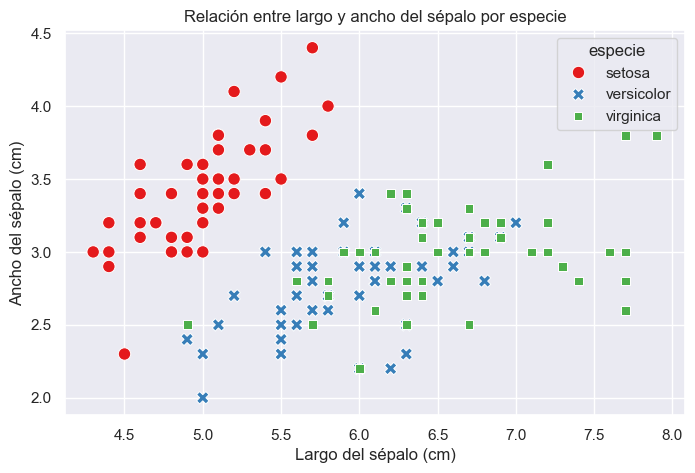

In [4]:
# Cargamos el conjunto de datos Iris desde scikit-learn
from sklearn.datasets import load_iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["especie"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Scatterplot para comparar largo vs ancho del sépalo y codificar la especie con colores y marcadores
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_iris, x="sepal length (cm)", y="sepal width (cm)",
                hue="especie", style="especie", palette="Set1", s=80, ax=ax)
ax.set_title("Relación entre largo y ancho del sépalo por especie")
ax.set_xlabel("Largo del sépalo (cm)")
ax.set_ylabel("Ancho del sépalo (cm)")
plt.show()

### 2.2 Pairplot (gráficos de pares)

Cuando trabajas con más de dos variables numéricas, resulta útil visualizar todas las combinaciones posibles. La función **pairplot()** crea automáticamente una cuadrícula de gráficos donde cada fila y columna corresponde a una variable y se muestran las relaciones bivariadas y las distribuciones univariadas.

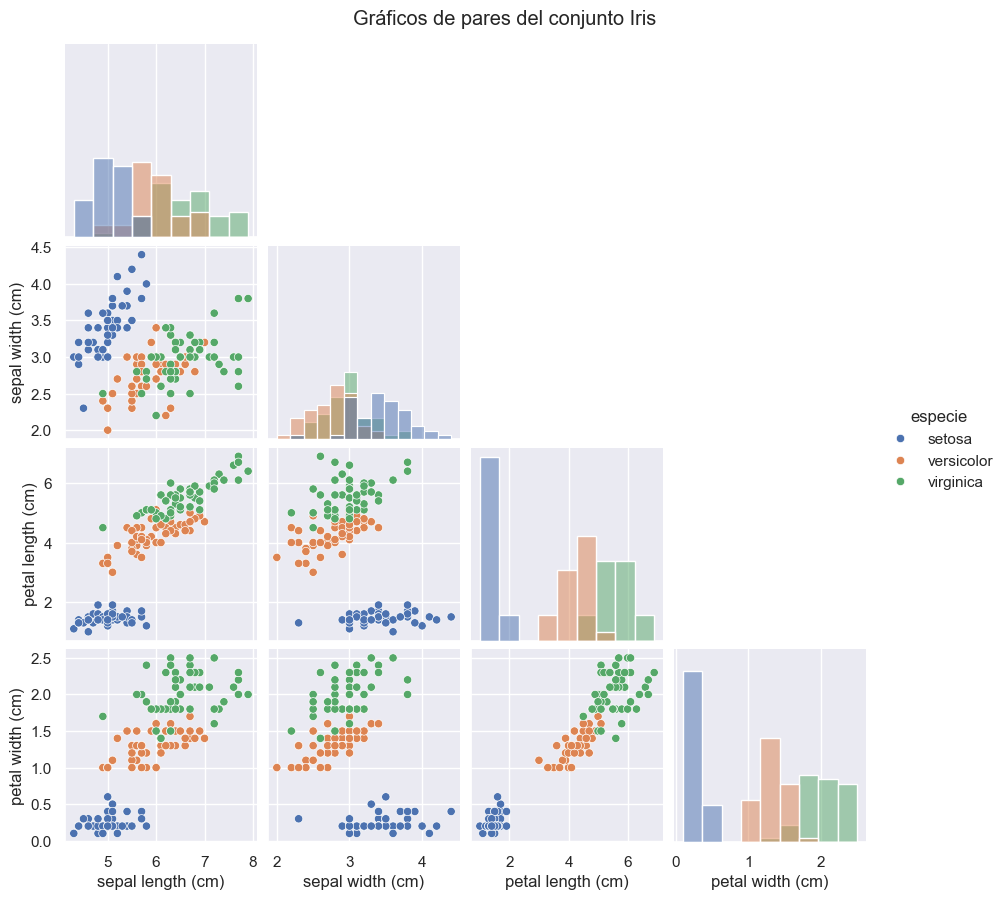

In [5]:
# Pairplot para todas las variables numéricas del Iris
sns.pairplot(df_iris, hue="especie", corner=True, diag_kind="hist", height=2.2)
plt.suptitle("Gráficos de pares del conjunto Iris", y=1.02)
plt.show()

### 2.3 Ajuste de regresiones

La función **regplot()** dibuja la nube de puntos y ajusta un modelo de regresión lineal. Puedes añadir líneas de confianza y estimar relaciones no lineales mediante polinomios o regresión LOWESS.

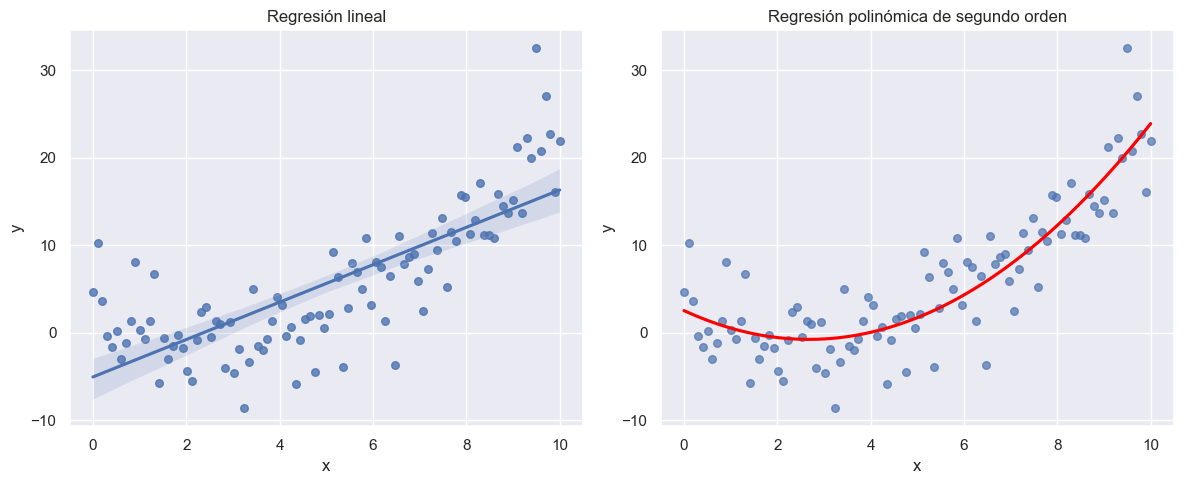

In [6]:
# Creamos una relación no lineal entre dos variables
np.random.seed(321)
x = np.linspace(0, 10, 100)
y = 0.5 * x**2 - 3 * x + 4 + np.random.normal(0, 4, size=len(x))

# DataFrame para regplot
df_reg = pd.DataFrame({"x": x, "y": y})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Ajuste lineal simple
sns.regplot(data=df_reg, x="x", y="y", ci=95, scatter_kws={"s": 30}, ax=axes[0])
axes[0].set_title("Regresión lineal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Ajuste polinómico de segundo orden (order=2)
sns.regplot(data=df_reg, x="x", y="y", order=2, ci=None, line_kws={"color": "red"},
            scatter_kws={"s": 30, "alpha": 0.7}, ax=axes[1])
axes[1].set_title("Regresión polinómica de segundo orden")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

## 3. Mapas de calor y matrices de correlación

Los **mapas de calor** representan matrices numéricas mediante colores. Son ideales para mostrar una **matriz de correlación**, donde cada celda indica la correlación entre dos variables, o para cruzar variables categóricas.

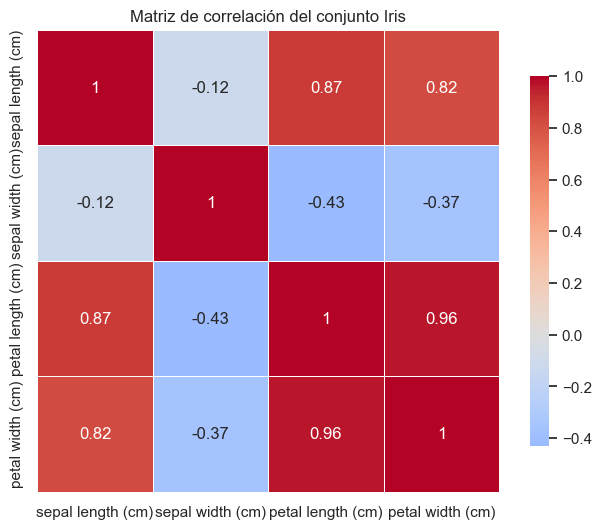

In [7]:
# Matriz de correlaciones de las variables del Iris
corr_matrix = df_iris.drop(columns=["especie"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación del conjunto Iris")
plt.show()

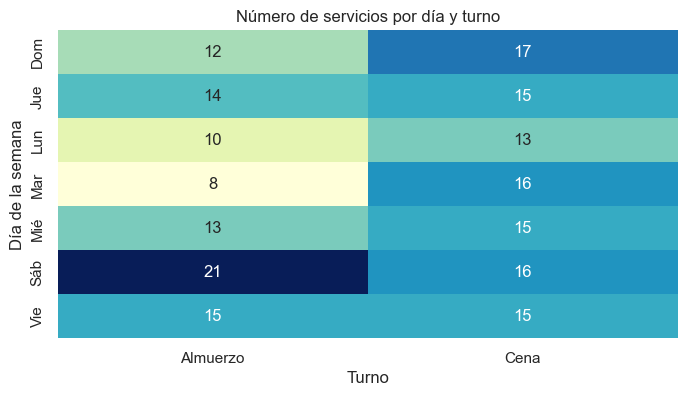

In [8]:
# Ejemplo de tabla de contingencia: contamos almuerzos y cenas en función del día de la semana
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
turnos = ["Almuerzo", "Cena"]
np.random.seed(456)
datos_cat = pd.DataFrame({
    "día": np.random.choice(dias, 200),
    "turno": np.random.choice(turnos, 200)
})

# Creamos tabla de contingencia
tabla = pd.crosstab(datos_cat["día"], datos_cat["turno"])

plt.figure(figsize=(8, 4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Número de servicios por día y turno")
plt.xlabel("Turno")
plt.ylabel("Día de la semana")
plt.show()

## 4. Capacidades estadísticas avanzadas de Seaborn

Una de las características más poderosas de Seaborn es su capacidad para realizar cálculos estadísticos complejos de forma automática. Detrás de una sola línea de código, Seaborn ejecuta algoritmos sofisticados que normalmente requerirían docenas de líneas en otras bibliotecas. En esta sección exploraremos las capacidades matemáticas y estadísticas más avanzadas que Seaborn ofrece directamente.

### 4.1 Clustering jerárquico con clustermap

El **clustermap** es una de las funciones más complejas de Seaborn desde el punto de vista algorítmico. No solo dibuja un mapa de calor: realiza un **clustering jerárquico aglomerativo completo** sobre tus datos.

El proceso matemático incluye:
1. Calcular una matriz de distancias entre todas las filas y columnas (usando métricas como distancia euclidiana, Manhattan o correlación)
2. Aplicar un algoritmo de enlace (linkage) que agrupa iterativamente los puntos más similares
3. Reordenar las filas y columnas para agrupar elementos similares
4. Generar dendrogramas (árboles jerárquicos) que muestran la estructura de agrupación

Esto es extremadamente útil para identificar patrones ocultos en datos multidimensionales, como expresión génica, segmentación de clientes o análisis de comportamiento.

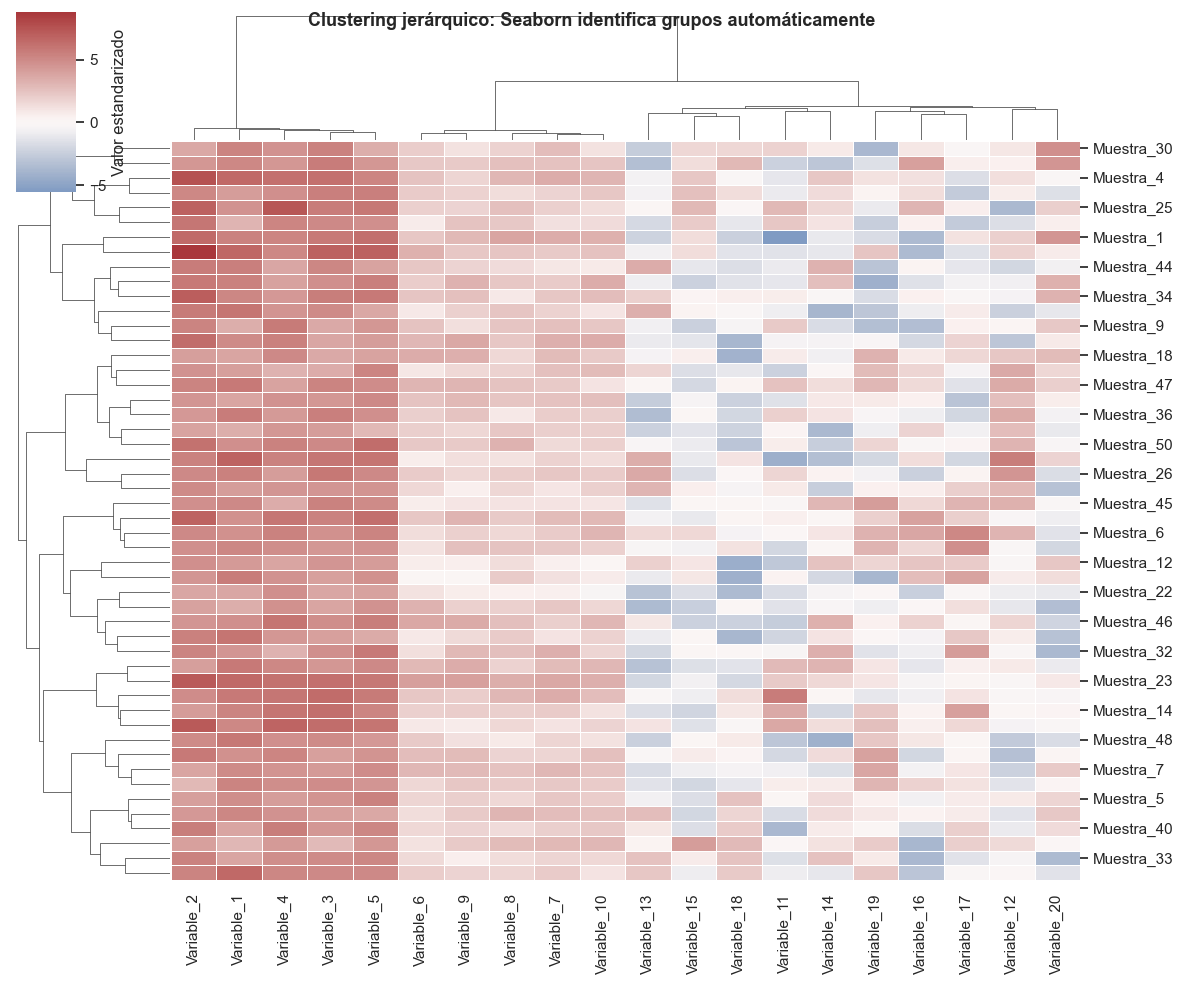

✓ Seaborn calculó matrices de distancia, aplicó clustering y reordenó automáticamente


In [9]:
# Generamos un conjunto de datos sintético con grupos naturales
np.random.seed(789)

# Crear diferentes "grupos" de variables con correlaciones internas
n_samples = 50
n_features = 20

# Grupo 1: variables correlacionadas positivamente
grupo1 = np.random.multivariate_normal([5, 5, 5, 5, 5], 
                                       np.eye(5) * 0.5 + 0.5, 
                                       size=n_samples)

# Grupo 2: variables correlacionadas negativamente con el grupo 1
grupo2 = np.random.multivariate_normal([2, 2, 2, 2, 2], 
                                       np.eye(5) * 0.3 + 0.3, 
                                       size=n_samples)

# Grupo 3: variables independientes
grupo3 = np.random.randn(n_samples, 10) * 2

# Combinar todos los datos
datos_cluster = np.hstack([grupo1, grupo2, grupo3])

# Crear DataFrame con nombres de filas y columnas
df_cluster = pd.DataFrame(
    datos_cluster,
    columns=[f"Variable_{i+1}" for i in range(20)],
    index=[f"Muestra_{i+1}" for i in range(n_samples)]
)

# Aplicar clustermap con clustering jerárquico
# Seaborn calcula automáticamente distancias, agrupa datos similares y reorganiza
sns.clustermap(df_cluster, 
               cmap="vlag",           # Paleta de colores divergente
               center=0,              # Centrar en cero
               figsize=(12, 10),
               cbar_kws={"label": "Valor estandarizado"},
               method="ward",         # Método de enlace: Ward minimiza varianza
               metric="euclidean",    # Métrica de distancia
               row_cluster=True,      # Agrupar filas
               col_cluster=True,      # Agrupar columnas
               dendrogram_ratio=0.15, # Proporción del dendrograma
               linewidths=0.5)

plt.suptitle("Clustering jerárquico: Seaborn identifica grupos automáticamente", 
            y=0.98, fontsize=13, fontweight='bold')
plt.show()

print("✓ Seaborn calculó matrices de distancia, aplicó clustering y reordenó automáticamente")

### 4.2 Regresión avanzada con intervalos de confianza bootstrapping

Aunque dibujar una línea de regresión lineal es matemáticamente simple, Seaborn va mucho más allá. Las bandas de confianza que ves alrededor de las líneas no son simples desviaciones estándar: son **intervalos de confianza calculados mediante bootstrapping**.

**Bootstrapping**: Seaborn remuestrea tus datos con reemplazo miles de veces, ajusta una nueva regresión para cada muestra y calcula la varianza. Este es un método estadísticamente robusto pero computacionalmente intensivo.

Además, Seaborn ofrece:
- **LOWESS** (Locally Weighted Scatterplot Smoothing): regresión local no paramétrica que captura tendencias complejas
- **Regresión robusta**: reduce iterativamente el peso de los valores atípicos para que no distorsionen la línea

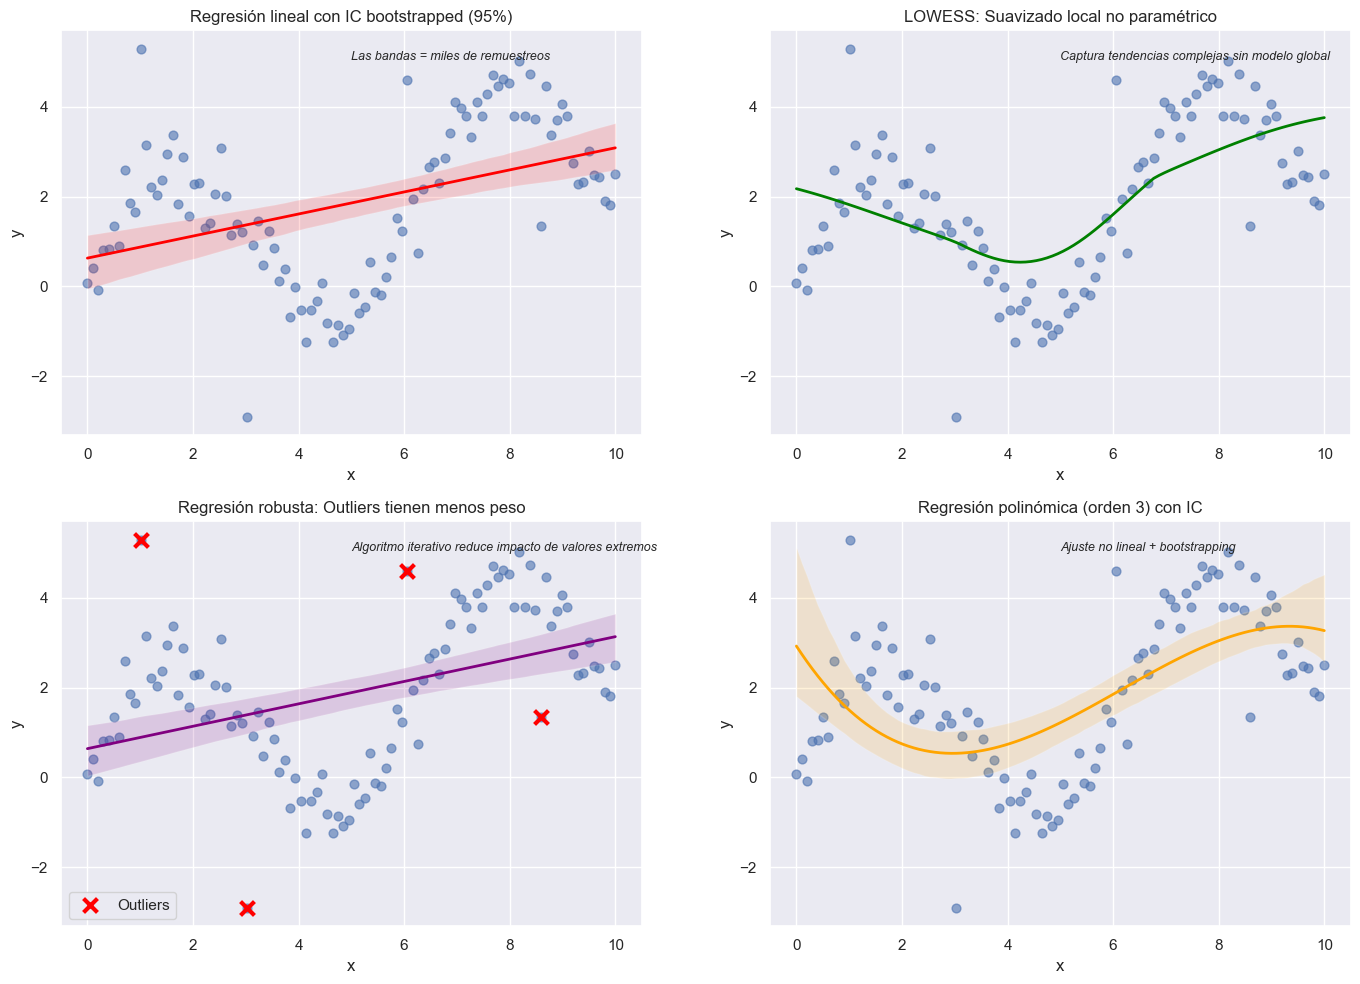

✓ Cada línea representa miles de cálculos estadísticos automáticos


In [10]:
# Generamos datos con una relación no lineal y algunos outliers
np.random.seed(555)
x_reg = np.linspace(0, 10, 100)
y_reg = 2 * np.sin(x_reg) + 0.3 * x_reg + np.random.normal(0, 0.5, size=len(x_reg))

# Añadimos algunos valores atípicos intencionalmente
outliers_idx = [10, 30, 60, 85]
y_reg[outliers_idx] += np.array([3, -4, 3.5, -3])

df_reg_advanced = pd.DataFrame({"x": x_reg, "y": y_reg})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Regresión lineal estándar con intervalo de confianza bootstrapped
sns.regplot(data=df_reg_advanced, x="x", y="y", 
           ax=axes[0, 0],
           scatter_kws={"s": 40, "alpha": 0.6},
           line_kws={"color": "red", "linewidth": 2})
axes[0, 0].set_title("Regresión lineal con IC bootstrapped (95%)")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("y")
axes[0, 0].text(0.5, 0.95, "Las bandas = miles de remuestreos", 
               transform=axes[0, 0].transAxes, 
               fontsize=9, va='top', style='italic')

# 2. LOWESS: regresión local no paramétrica
sns.regplot(data=df_reg_advanced, x="x", y="y",
           lowess=True,  # ¡Aquí está la magia matemática!
           ax=axes[0, 1],
           scatter_kws={"s": 40, "alpha": 0.6},
           line_kws={"color": "green", "linewidth": 2})
axes[0, 1].set_title("LOWESS: Suavizado local no paramétrico")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel("y")
axes[0, 1].text(0.5, 0.95, "Captura tendencias complejas sin modelo global", 
               transform=axes[0, 1].transAxes, 
               fontsize=9, va='top', style='italic')

# 3. Regresión robusta: reduce influencia de outliers
sns.regplot(data=df_reg_advanced, x="x", y="y",
           robust=True,  # Reponderación iterativa de outliers
           ax=axes[1, 0],
           scatter_kws={"s": 40, "alpha": 0.6},
           line_kws={"color": "purple", "linewidth": 2})
axes[1, 0].set_title("Regresión robusta: Outliers tienen menos peso")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel("y")
axes[1, 0].text(0.5, 0.95, "Algoritmo iterativo reduce impacto de valores extremos", 
               transform=axes[1, 0].transAxes, 
               fontsize=9, va='top', style='italic')

# Marcamos los outliers
axes[1, 0].scatter(x_reg[outliers_idx], y_reg[outliers_idx], 
                  color='red', s=100, marker='x', linewidths=3, 
                  label='Outliers', zorder=5)
axes[1, 0].legend()

# 4. Regresión polinómica con bootstrapping
sns.regplot(data=df_reg_advanced, x="x", y="y",
           order=3,  # Polinomio de grado 3
           ax=axes[1, 1],
           scatter_kws={"s": 40, "alpha": 0.6},
           line_kws={"color": "orange", "linewidth": 2})
axes[1, 1].set_title("Regresión polinómica (orden 3) con IC")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel("y")
axes[1, 1].text(0.5, 0.95, "Ajuste no lineal + bootstrapping", 
               transform=axes[1, 1].transAxes, 
               fontsize=9, va='top', style='italic')

plt.tight_layout()
plt.show()

print("✓ Cada línea representa miles de cálculos estadísticos automáticos")

### 4.3 Estimación de densidad de kernel bivariada (KDE 2D)

Mientras que una KDE unidimensional suaviza un histograma, una **KDE bivariada** es matemáticamente mucho más compleja. Seaborn evalúa una **función de densidad de probabilidad conjunta** sobre una cuadrícula 2D densa.

El proceso matemático:
1. Calcula la distribución de probabilidad conjunta de dos variables simultáneamente
2. Estima la matriz de varianza-covarianza para capturar la relación entre las variables
3. Coloca kernels gaussianos (o de otro tipo) en cada punto de datos
4. Suma todas las contribuciones para crear contornos topográficos que muestran dónde se concentra la densidad de datos

Esto es fundamental para identificar **estructuras multivariadas**, como múltiples modas, correlaciones no lineales o agrupaciones naturales en datos 2D.

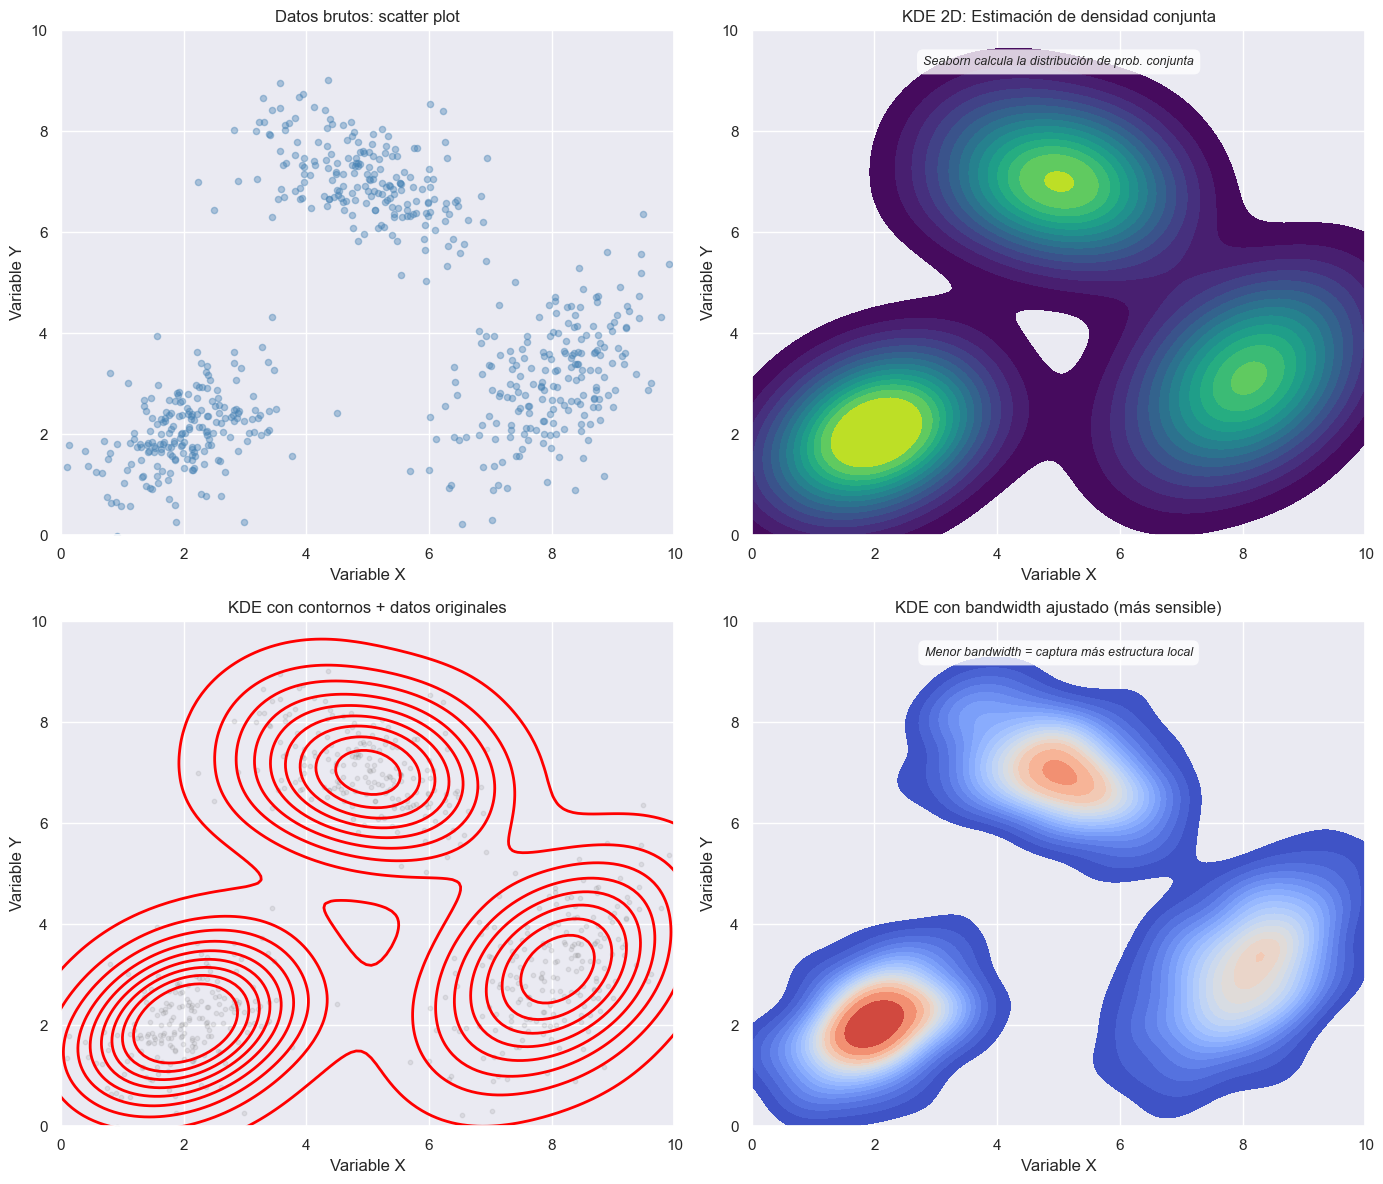

✓ Seaborn evaluó una función de densidad 2D completa sobre una cuadrícula


In [11]:
# Generamos datos con múltiples grupos (distribución multimodal)
np.random.seed(999)

# Tres "clusters" con diferentes centros y dispersiones
n_por_grupo = 200

cluster1 = np.random.multivariate_normal([2, 2], [[0.5, 0.2], [0.2, 0.5]], n_por_grupo)
cluster2 = np.random.multivariate_normal([5, 7], [[0.8, -0.3], [-0.3, 0.6]], n_por_grupo)
cluster3 = np.random.multivariate_normal([8, 3], [[0.6, 0.4], [0.4, 1.0]], n_por_grupo)

# Combinar todos los datos
datos_kde = np.vstack([cluster1, cluster2, cluster3])
df_kde = pd.DataFrame(datos_kde, columns=["Variable_X", "Variable_Y"])

# Crear figura con múltiples visualizaciones de KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Scatter plot simple (sin procesar)
axes[0, 0].scatter(df_kde["Variable_X"], df_kde["Variable_Y"], 
                  alpha=0.4, s=20, color='steelblue')
axes[0, 0].set_title("Datos brutos: scatter plot")
axes[0, 0].set_xlabel("Variable X")
axes[0, 0].set_ylabel("Variable Y")
axes[0, 0].set_xlim(0, 10)
axes[0, 0].set_ylim(0, 10)

# 2. KDE bivariada con contornos rellenos
sns.kdeplot(data=df_kde, x="Variable_X", y="Variable_Y",
           fill=True,           # Rellenar contornos
           cmap="viridis",      # Mapa de colores
           levels=15,           # Número de niveles de contorno
           thresh=0.05,         # Umbral mínimo de densidad
           ax=axes[0, 1])
axes[0, 1].set_title("KDE 2D: Estimación de densidad conjunta")
axes[0, 1].set_xlabel("Variable X")
axes[0, 1].set_ylabel("Variable Y")
axes[0, 1].set_xlim(0, 10)
axes[0, 1].set_ylim(0, 10)
axes[0, 1].text(0.5, 0.95, "Seaborn calcula la distribución de prob. conjunta", 
               transform=axes[0, 1].transAxes, 
               fontsize=9, va='top', ha='center', style='italic',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none'),
               zorder=10)

# 3. KDE con líneas de contorno y puntos
sns.kdeplot(data=df_kde, x="Variable_X", y="Variable_Y",
           levels=10,
           color="red",
           linewidths=2,
           ax=axes[1, 0])
axes[1, 0].scatter(df_kde["Variable_X"], df_kde["Variable_Y"], 
                  alpha=0.15, s=10, color='gray')
axes[1, 0].set_title("KDE con contornos + datos originales")
axes[1, 0].set_xlabel("Variable X")
axes[1, 0].set_ylabel("Variable Y")
axes[1, 0].set_xlim(0, 10)
axes[1, 0].set_ylim(0, 10)

# 4. KDE con ancho de banda personalizado
sns.kdeplot(data=df_kde, x="Variable_X", y="Variable_Y",
           fill=True,
           cmap="coolwarm",
           levels=20,
           bw_adjust=0.5,  # Reducir ancho de banda = + detalle, - suavizado
           ax=axes[1, 1])
axes[1, 1].set_title("KDE con bandwidth ajustado (más sensible)")
axes[1, 1].set_xlabel("Variable X")
axes[1, 1].set_ylabel("Variable Y")
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_ylim(0, 10)
axes[1, 1].text(0.5, 0.95, "Menor bandwidth = captura más estructura local", 
               transform=axes[1, 1].transAxes, 
               fontsize=9, va='top', ha='center', style='italic',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='none'),
               zorder=10)

plt.tight_layout()
plt.show()

print("✓ Seaborn evaluó una función de densidad 2D completa sobre una cuadrícula")

### 4.4 Estimaciones categóricas con intervalos de confianza bootstrapped

Cuando usas `sns.barplot()` o `sns.pointplot()`, las barras de error que ves no son simples desviaciones estándar. Por defecto, Seaborn utiliza **bootstrapping** para calcular intervalos de confianza rigurosos.

El proceso:
1. Toma miles de muestras aleatorias (con reemplazo) de tus datos
2. Calcula el estadístico (media, mediana, etc.) para cada muestra
3. Obtiene la distribución de ese estadístico
4. Calcula los percentiles para determinar el intervalo de confianza (típicamente 95%)

Esto proporciona una **garantía estadística robusta** de dónde probablemente se encuentra el verdadero parámetro poblacional, mucho más sólida que un simple error estándar. Es inferencia estadística completa en una sola línea de código.

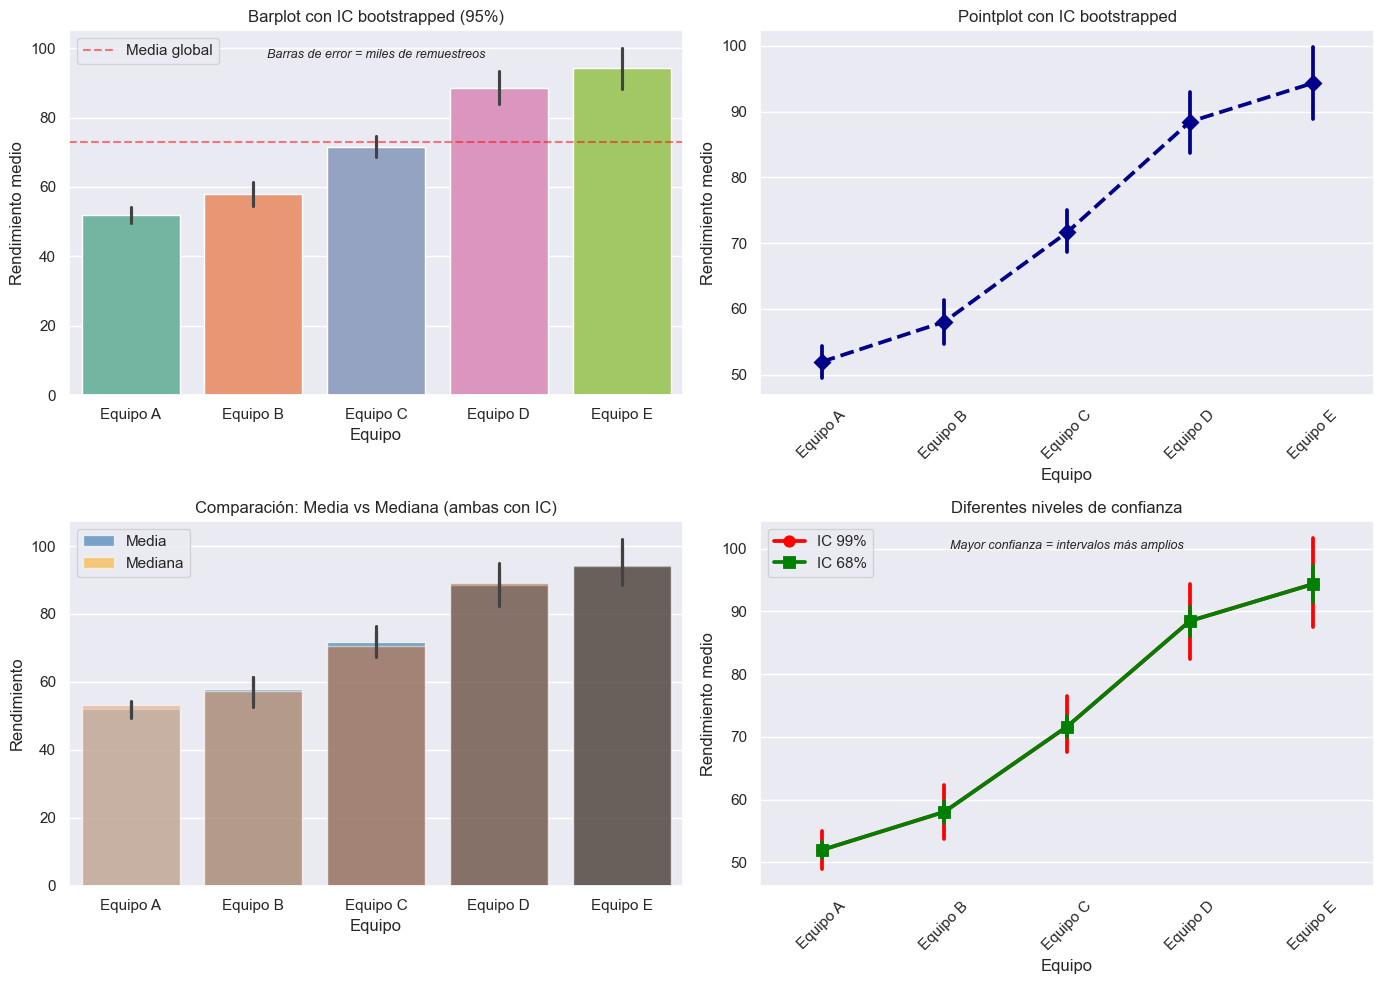

✓ Seaborn ejecutó miles de iteraciones de bootstrapping para cada estadístico
✓ Con 40 observaciones por equipo y 5 equipos, se procesaron automáticamente


In [12]:
# Simulamos datos de rendimiento de diferentes equipos con variabilidad
np.random.seed(444)

equipos = ["Equipo A", "Equipo B", "Equipo C", "Equipo D", "Equipo E"]
n_observaciones = 40

# Cada equipo tiene diferente media y varianza
datos_equipos = []
for i, equipo in enumerate(equipos):
    media = 50 + i * 10 + np.random.randn() * 5  # Medias diferentes
    std = 8 + i * 2  # Varianzas diferentes
    valores = np.random.normal(media, std, n_observaciones)
    
    for valor in valores:
        datos_equipos.append({"Equipo": equipo, "Rendimiento": valor})

df_equipos = pd.DataFrame(datos_equipos)

# Crear figura comparativa
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Barplot con intervalo de confianza bootstrapped (95%)
sns.barplot(data=df_equipos, x="Equipo", y="Rendimiento",
           hue="Equipo",  # Asignar hue para usar palette
           errorbar=("ci", 95),  # Intervalo de confianza del 95% via bootstrapping
           palette="Set2",
           legend=False,  # No mostrar leyenda redundante
           ax=axes[0, 0])
axes[0, 0].set_title("Barplot con IC bootstrapped (95%)")
axes[0, 0].set_ylabel("Rendimiento medio")
axes[0, 0].axhline(y=df_equipos["Rendimiento"].mean(), 
                   color='red', linestyle='--', alpha=0.5, label='Media global')
axes[0, 0].legend()
axes[0, 0].text(0.5, 0.95, "Barras de error = miles de remuestreos", 
               transform=axes[0, 0].transAxes, 
               fontsize=9, va='top', ha='center', style='italic')

# 2. Pointplot: muestra tendencias con IC bootstrapped
sns.pointplot(data=df_equipos, x="Equipo", y="Rendimiento",
             errorbar=("ci", 95),
             markers="D",
             linestyles="--",
             color="darkblue",
             ax=axes[0, 1])
axes[0, 1].set_title("Pointplot con IC bootstrapped")
axes[0, 1].set_ylabel("Rendimiento medio")
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Comparación de diferentes estimadores: media vs mediana
sns.barplot(data=df_equipos, x="Equipo", y="Rendimiento",
           hue="Equipo",  # Asignar hue para usar palette
           estimator=np.mean,  # Usar la media
           errorbar=("ci", 95),
           palette="Blues_d",
           alpha=0.7,
           legend=False,
           ax=axes[1, 0])
sns.barplot(data=df_equipos, x="Equipo", y="Rendimiento",
           hue="Equipo",  # Asignar hue para usar palette
           estimator=np.median,  # Usar la mediana
           errorbar=("ci", 95),
           palette="Oranges_d",
           alpha=0.5,
           legend=False,
           ax=axes[1, 0])

# Crear leyenda manual para los dos conjuntos de barras
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Media'),
                  Patch(facecolor='orange', alpha=0.5, label='Mediana')]
axes[1, 0].legend(handles=legend_elements)

axes[1, 0].set_title("Comparación: Media vs Mediana (ambas con IC)")
axes[1, 0].set_ylabel("Rendimiento")

# 4. Diferentes niveles de confianza
sns.pointplot(data=df_equipos, x="Equipo", y="Rendimiento",
             errorbar=("ci", 99),  # 99% de confianza
             color="red",
             markers="o",
             label="IC 99%",
             ax=axes[1, 1])
sns.pointplot(data=df_equipos, x="Equipo", y="Rendimiento",
             errorbar=("ci", 68),  # 68% (≈ 1 std)
             color="green",
             markers="s",
             label="IC 68%",
             ax=axes[1, 1])
axes[1, 1].set_title("Diferentes niveles de confianza")
axes[1, 1].set_ylabel("Rendimiento medio")
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].text(0.5, 0.95, "Mayor confianza = intervalos más amplios", 
               transform=axes[1, 1].transAxes, 
               fontsize=9, va='top', ha='center', style='italic')

plt.tight_layout()
plt.show()

print("✓ Seaborn ejecutó miles de iteraciones de bootstrapping para cada estadístico")
print(f"✓ Con {n_observaciones} observaciones por equipo y 5 equipos, se procesaron automáticamente")

## 5. Estilo y paletas de colores

Seaborn permite controlar la apariencia de los gráficos mediante temas y paletas. Puedes ajustar el contexto para cambiar el tamaño de fuente, seleccionar un estilo de ejes y escoger paletas coherentes con tus datos.

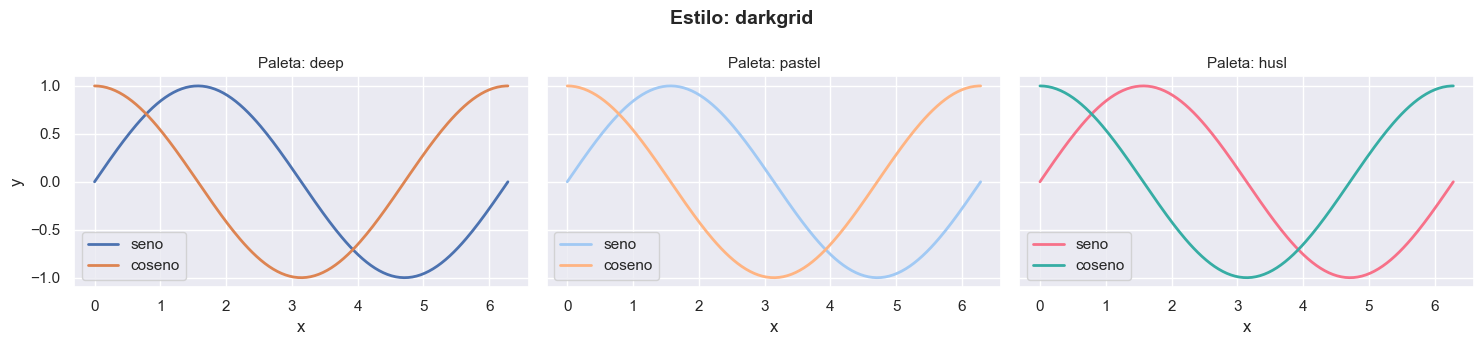

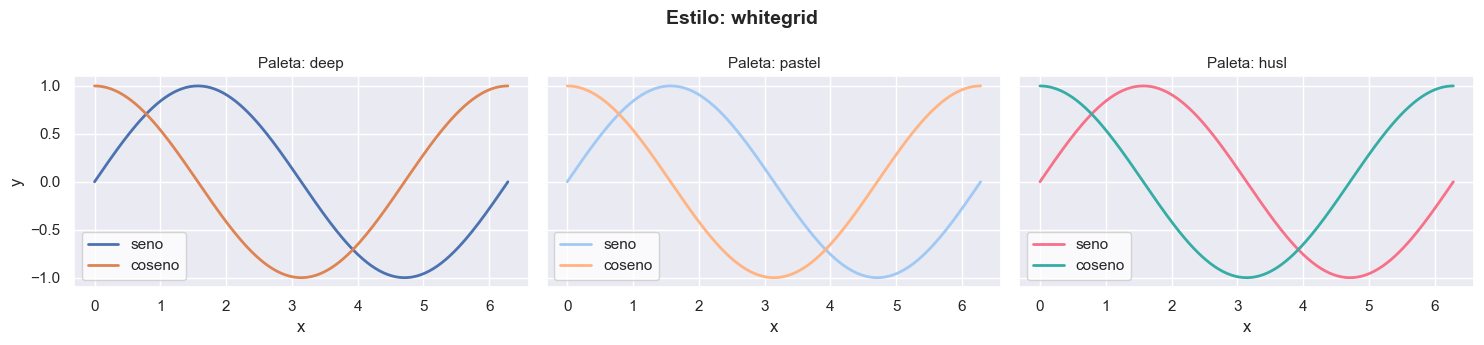

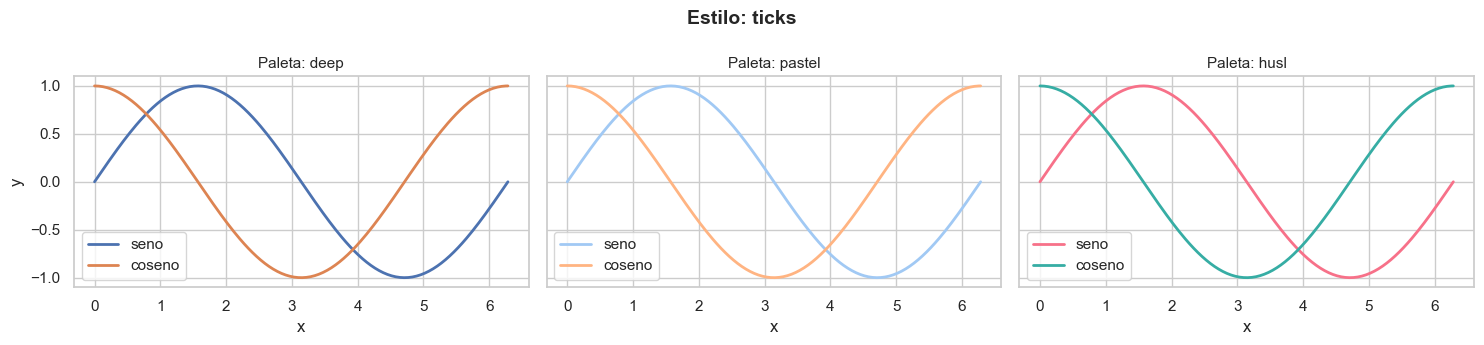

In [ ]:
# Demostración de diferentes estilos y paletas
# Crear datos para ilustración
x = np.linspace(0, 2 * np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)

estilos = ["darkgrid", "whitegrid", "ticks"]
paletas = ["deep", "pastel", "husl"]

# Crear una figura para cada combinación de estilo y paleta
for i, estilo in enumerate(estilos):
    fig, axes = plt.subplots(1, len(paletas), figsize=(15, 3.5), sharex=True, sharey=True)
    fig.suptitle(f"Estilo: {estilo}", fontsize=14, fontweight='bold')
    
    for j, paleta in enumerate(paletas):
        # Establecer el tema antes de graficar
        sns.set_theme(style=estilo, palette=paleta)
        
        # Obtener los colores de la paleta actual
        colors = sns.color_palette(paleta, n_colors=2)
        
        # Crear los datos para este subplot
        data_plot = pd.DataFrame({'x': x, 'seno': y_sin, 'coseno': y_cos})
        
        # Graficar con colores específicos de la paleta
        sns.lineplot(data=data_plot, x='x', y='seno', label="seno", ax=axes[j], 
                    linewidth=2, color=colors[0])
        sns.lineplot(data=data_plot, x='x', y='coseno', label="coseno", ax=axes[j], 
                    linewidth=2, color=colors[1])
        
        axes[j].set_title(f"Paleta: {paleta}", fontsize=11)
        axes[j].set_xlabel("x")
        axes[j].set_ylabel("y" if j == 0 else "")
        axes[j].legend()
    
    plt.tight_layout()
    plt.show()

# Restablecemos el tema por defecto para los siguientes gráficos
sns.set_theme()

## 6. Ejercicios propuestos

1. **Histogramas personalizados**: genera un conjunto de datos numéricos y crea un histograma comparando el efecto de diferentes números de barras y la opción `binwidth`.
2. **Detección de outliers**: crea un conjunto de datos con múltiples categorías y valores extremos. Visualízalo con un boxplot y un violin plot. ¿Qué diferencias observas?
3. **Análisis multivariante**: elige un conjunto de datos con al menos cuatro variables numéricas (puede ser el de Iris o uno propio) y genera un `pairplot()`. Añade un parámetro `hue` para una variable categórica y modifica `diag_kind`.
4. **Regresiones**: genera un conjunto de datos con ruido y ajusta modelos lineales y polinómicos de distintos grados usando `regplot()`. Compara visualmente los ajustes.
5. **Matrices de correlación**: toma cualquier DataFrame numérico y calcula su matriz de correlación. Representa la matriz con un mapa de calor y experimenta con diferentes paletas de colores y configuraciones como `center`, `vmin` y `vmax`.
6. **Clustering jerárquico**: crea una matriz de datos sintéticos con grupos naturales y usa `clustermap()` con diferentes métricas de distancia (`euclidean`, `correlation`, `manhattan`) y métodos de enlace (`ward`, `average`, `complete`). Observa cómo cambia la agrupación.
7. **KDE bivariada**: genera datos con dos o tres "clusters" y visualízalos con `kdeplot()` 2D. Experimenta con diferentes valores de `bw_adjust` para ver cómo afecta el suavizado.
8. **Bootstrapping**: crea datos categóricos con diferentes tamaños de muestra por categoría. Compara los intervalos de confianza resultantes y observa cómo el tamaño muestral afecta la incertidumbre.

### Conclusión

En este módulo has aprendido a utilizar Seaborn para explorar distribuciones de datos, analizar relaciones entre variables y visualizar matrices de correlación. Además, has descubierto las capacidades estadísticas avanzadas que Seaborn ejecuta automáticamente: clustering jerárquico, regresiones robustas con bootstrapping, estimaciones de densidad bivariadas y cálculos de intervalos de confianza rigurosos. 

Estas herramientas te permiten realizar análisis estadísticos complejos y crear visualizaciones profesionales con pocas líneas de código. Practicar con ellas te permitirá contar historias basadas en datos de forma clara, precisa y estadísticamente sólida. En el siguiente módulo trabajaremos con Plotly para añadir interactividad a tus visualizaciones.